# Phase 1: Exploratory Data Analysis (EDA) - USA Dataset
First, we will import the necessary data science libraries, set up our plotting style, and load our engineered USA moderate dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the dataset using the exact file path
file_path = '/content/drive/MyDrive/wheat_yield_india/dataset/final_usa_wheat_dataset_moderate.csv'
df_usa = pd.read_csv(file_path)

# 3. Initial Inspection
print("Dataset Shape:", df_usa.shape)
print("\nData Types:")
print(df_usa.dtypes)

print("\nFirst 5 Rows:")
display(df_usa.head())

Mounted at /content/drive
Dataset Shape: (14038, 24)

Data Types:
Country                         object
Dist Code                        int64
State                           object
District                        object
Year                             int64
Yield                          float64
Avg_Season_Tmax                float64
Total_Season_Rain              float64
Sowing_Rainfall                float64
Terminal_Heat_Tmax             float64
Temperature_Anomaly            float64
Rainfall_Deviation             float64
Yield_Lag2                     float64
Yield_Rolling_Mean3            float64
Yield_Rolling_Std3             float64
Avg_Season_Tmax_Anomaly        float64
Total_Season_Rain_Anomaly      float64
Sowing_Rainfall_Anomaly        float64
Terminal_Heat_Tmax_Anomaly     float64
Temperature_Anomaly_Anomaly    float64
Rainfall_Deviation_Anomaly     float64
Terminal_vs_AvgTemp            float64
SowingRain_to_TotalRain        float64
Rain_per_Temp                  float6

,Country,Dist Code,State,District,Year,Yield,Avg_Season_Tmax,Total_Season_Rain,Sowing_Rainfall,Terminal_Heat_Tmax,...,Yield_Rolling_Std3,Avg_Season_Tmax_Anomaly,Total_Season_Rain_Anomaly,Sowing_Rainfall_Anomaly,Terminal_Heat_Tmax_Anomaly,Temperature_Anomaly_Anomaly,Rainfall_Deviation_Anomaly,Terminal_vs_AvgTemp,SowingRain_to_TotalRain,Rain_per_Temp
0,USA,6095,CA,SOLANO,2000,5991.975,28.015,12.99,0.00,39.96,...,0.000000,-0.309769,-1.585897,-0.811795,3.140769,-0.309769,-1.585897,11.945,0.000000,0.463680
1,USA,6095,CA,SOLANO,2000,1956.975,28.015,12.99,0.00,39.96,...,2853.175862,-0.309769,-1.585897,-0.811795,3.140769,-0.309769,-1.585897,11.945,0.000000,0.463680
2,USA,6095,CA,SOLANO,2001,4875.625,29.611,11.17,2.11,39.74,...,2083.505865,1.286231,-3.405897,1.298205,2.920769,1.286231,-3.405897,10.129,0.173377,0.377225
3,USA,6095,CA,SOLANO,2001,5649.000,29.611,11.17,2.11,39.74,...,1947.120751,1.286231,-3.405897,1.298205,2.920769,1.286231,-3.405897,10.129,0.173377,0.377225
4,USA,6095,CA,SOLANO,2001,1008.750,29.611,11.17,2.11,39.74,...,2486.052802,1.286231,-3.405897,1.298205,2.920769,1.286231,-3.405897,10.129,0.173377,0.377225


### Missing Values & Statistical Summary
Before diving into visualizations, we must ensure our rolling averages and lag features didn't leave behind unhandled null values. We will also look at the mathematical spread of our agricultural and climate features.

In [2]:
# Check for missing values
print("Missing Values per Column:")
print(df_usa.isnull().sum()[df_usa.isnull().sum() > 0])

# Generate statistical summary of numerical features
numerical_cols = ['Yield', 'Yield_Lag2', 'Yield_Rolling_Mean3', 'Avg_Season_Tmax',
                  'Total_Season_Rain', 'Sowing_Rainfall', 'Terminal_Heat_Tmax',
                  'Temperature_Anomaly', 'Rainfall_Deviation']

print("\nStatistical Summary:")
display(df_usa[numerical_cols].describe().round(2))

Missing Values per Column:
Series([], dtype: int64)

Statistical Summary:


,Yield,Yield_Lag2,Yield_Rolling_Mean3,Avg_Season_Tmax,Total_Season_Rain,Sowing_Rainfall,Terminal_Heat_Tmax,Temperature_Anomaly,Rainfall_Deviation
count,14038.00,14038.00,14038.00,14038.00,14038.00,14038.00,14038.00,14038.00,14038.00
mean,2961.35,2950.11,2958.57,24.63,14.85,2.83,34.24,-0.00,0.09
std,1609.02,1593.17,1324.93,4.47,6.92,1.78,4.04,1.13,3.74
min,0.00,0.00,277.97,10.19,2.71,0.00,20.10,-4.72,-18.11
25%,1950.25,1950.25,2089.23,21.31,10.30,1.65,31.48,-0.68,-2.43
50%,2690.00,2690.00,2705.69,24.99,13.69,2.58,34.50,0.05,0.10
75%,3577.70,3564.25,3429.75,28.21,17.75,3.83,37.39,0.76,2.37
max,10390.12,10343.05,10022.49,37.74,62.48,14.52,45.21,4.12,24.92


### Target Variable Distribution: Yield
We plot the distribution of our dependent variable (`Yield`). Because farming infrastructure and baseline climates vary greatly across US states, understanding the skewness of the yield distribution helps us set baseline expectations for the regression models later.

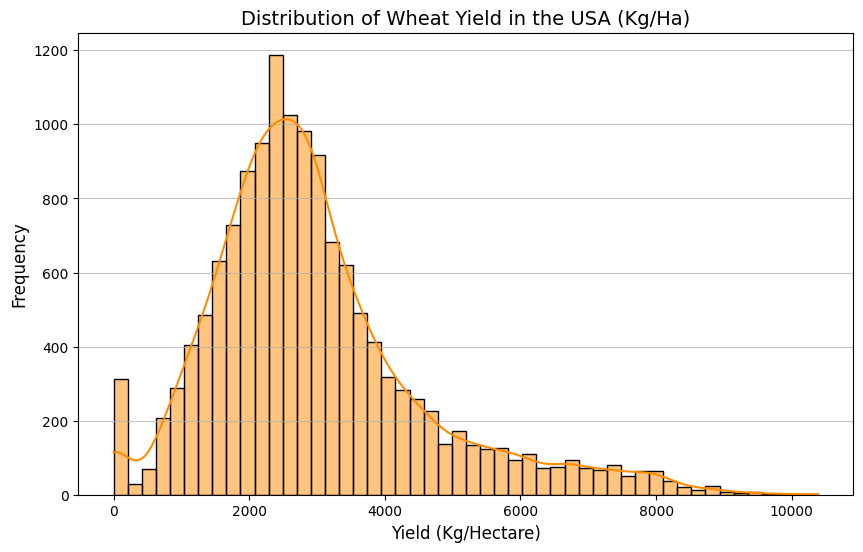

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df_usa['Yield'], bins=50, kde=True, color='darkorange')
plt.title('Distribution of Wheat Yield in the USA (Kg/Ha)', fontsize=14)
plt.xlabel('Yield (Kg/Hectare)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

### Correlation Analysis
This heatmap visualizes the linear relationships between American weather features and crop yield. We will look closely at `Yield_Rolling_Mean3` and `Terminal_Heat_Tmax`. Comparing these correlation numbers to the Indian dataset proves our comparative dashboard will provide highly valuable, distinct regional insights.

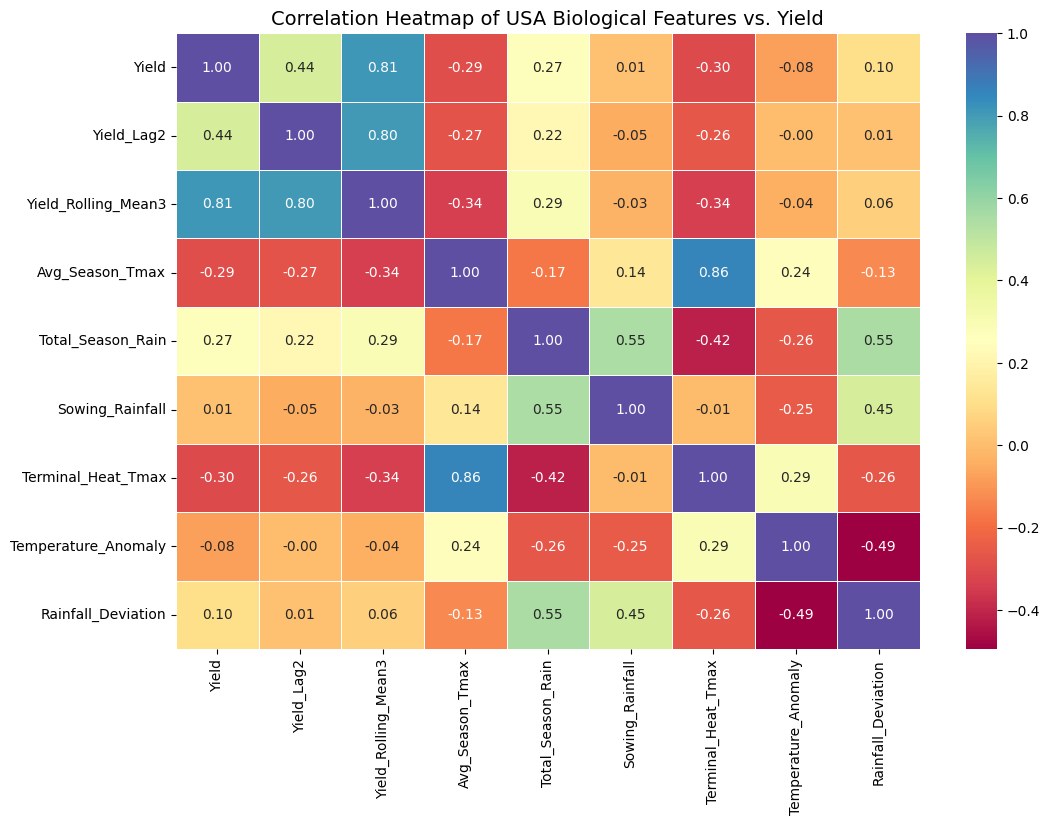

In [4]:
plt.figure(figsize=(12, 8))

# Calculate the correlation matrix on numerical columns only
corr_matrix = df_usa[numerical_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Spectral', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of USA Biological Features vs. Yield', fontsize=14)
plt.show()

### Temporal Trends & Feature Distributions
Finally, we track the average American yield across our chronological timeline to observe historical growth patterns. We also map the exact distribution of our comparative "Equalizer Features" (Temperature Anomaly and Rainfall Deviation) for the US.

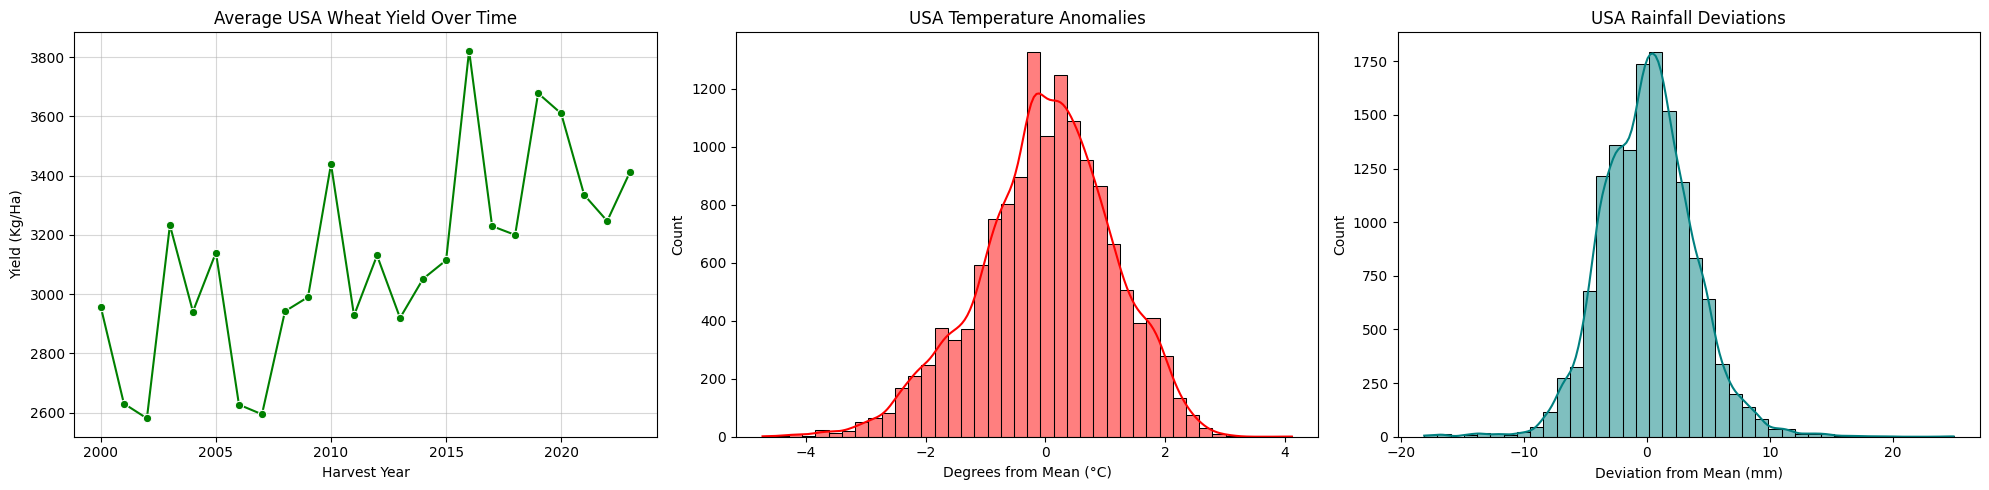

In [5]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Yield over Time
yearly_yield = df_usa.groupby('Year')['Yield'].mean().reset_index()
sns.lineplot(data=yearly_yield, x='Year', y='Yield', marker='o', color='green', ax=axes[0])
axes[0].set_title('Average USA Wheat Yield Over Time', fontsize=12)
axes[0].set_xlabel('Harvest Year')
axes[0].set_ylabel('Yield (Kg/Ha)')
axes[0].grid(True, alpha=0.5)

# Plot 2: Temperature Anomaly Distribution
sns.histplot(df_usa['Temperature_Anomaly'], bins=40, kde=True, color='red', ax=axes[1])
axes[1].set_title('USA Temperature Anomalies', fontsize=12)
axes[1].set_xlabel('Degrees from Mean (°C)')

# Plot 3: Rainfall Deviation Distribution
sns.histplot(df_usa['Rainfall_Deviation'], bins=40, kde=True, color='teal', ax=axes[2])
axes[2].set_title('USA Rainfall Deviations', fontsize=12)
axes[2].set_xlabel('Deviation from Mean (mm)')

plt.tight_layout()
plt.show()

### State-Level Yield Disparities (Geospatial Variance)
Farming infrastructure, soil quality, and irrigation access vary wildly across the US (e.g., Kansas vs. North Dakota). This boxplot compares the yield distribution across US states, ranking them from highest median yield to lowest.

/tmp/ipykernel_155/3995243920.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_usa, x='State', y='Yield', order=sorted_states_usa, palette='viridis')


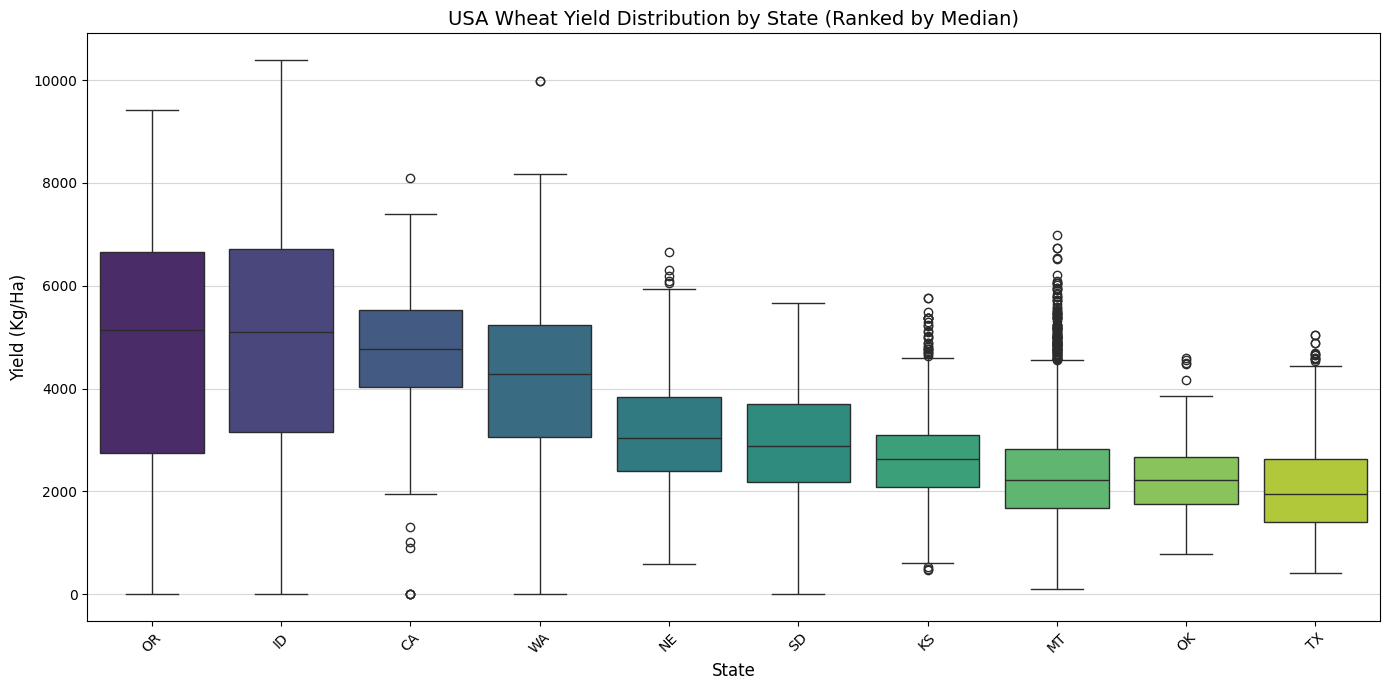

In [6]:
plt.figure(figsize=(14, 7))

# Sort states by their median yield for a cleaner looking chart
sorted_states_usa = df_usa.groupby('State')['Yield'].median().sort_values(ascending=False).index

sns.boxplot(data=df_usa, x='State', y='Yield', order=sorted_states_usa, palette='viridis')
plt.title('USA Wheat Yield Distribution by State (Ranked by Median)', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Yield (Kg/Ha)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

### The Danger of Terminal Heat in the USA
Terminal heat waves occurring exactly when winter wheat is in its critical grain-filling stage can be devastating. This scatter plot with a regression line tests how severely `Terminal_Heat_Tmax` crushes the final US yield.

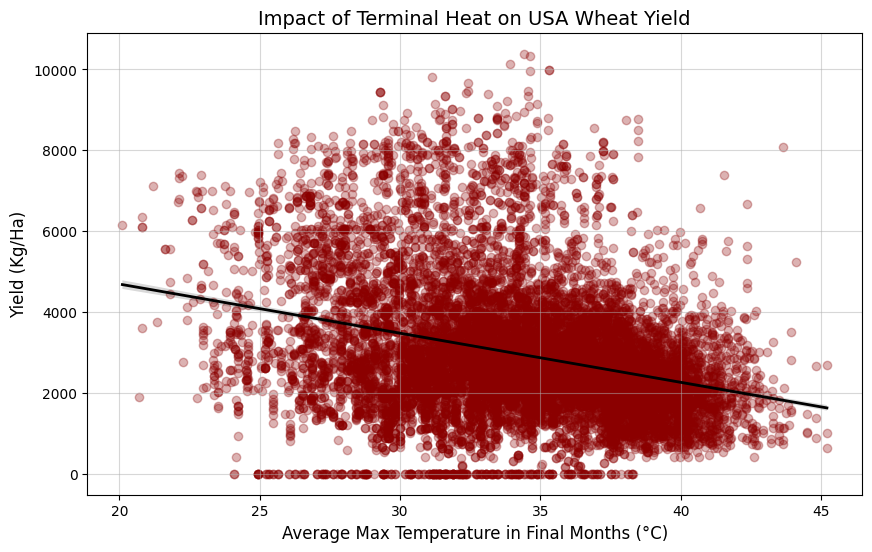

In [7]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df_usa, x='Terminal_Heat_Tmax', y='Yield',
            scatter_kws={'alpha':0.3, 'color': 'darkred'},
            line_kws={'color': 'black', 'linewidth': 2})

plt.title('Impact of Terminal Heat on USA Wheat Yield', fontsize=14)
plt.xlabel('Average Max Temperature in Final Months (°C)', fontsize=12)
plt.ylabel('Yield (Kg/Ha)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

### Categorizing Temperature Shocks (Heatwaves vs Normal)
We categorize our `Temperature_Anomaly` into distinct groups to see the categorical impact of extreme US heatwaves compared to baseline years.

/tmp/ipykernel_155/252535324.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_usa, x='Temp_Shock_Category', y='Yield', order=categories_t, palette='YlOrRd')


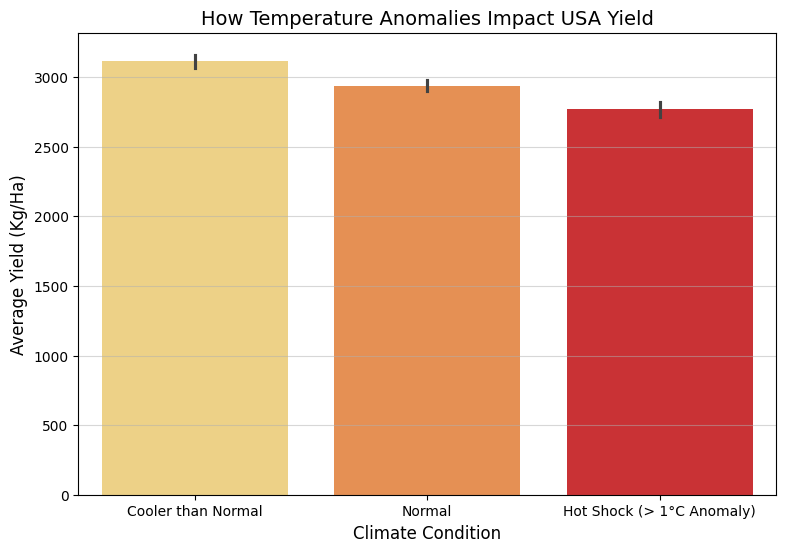

In [9]:
# Create categorical bins for temperature shocks
conditions_t = [
    (df_usa['Temperature_Anomaly'] < -0.5),
    (df_usa['Temperature_Anomaly'] >= -0.5) & (df_usa['Temperature_Anomaly'] <= 1.0),
    (df_usa['Temperature_Anomaly'] > 1.0)
]
categories_t = ['Cooler than Normal', 'Normal', 'Hot Shock (> 1°C Anomaly)']

df_usa['Temp_Shock_Category'] = np.select(conditions_t, categories_t, default='Unknown')

plt.figure(figsize=(9, 6))
sns.barplot(data=df_usa, x='Temp_Shock_Category', y='Yield', order=categories_t, palette='YlOrRd')
plt.title('How Temperature Anomalies Impact USA Yield', fontsize=14)
plt.xlabel('Climate Condition', fontsize=12)
plt.ylabel('Average Yield (Kg/Ha)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

# Clean up temporary column
df_usa = df_usa.drop(columns=['Temp_Shock_Category'])

### Categorizing Rainfall Shocks (Droughts vs Floods)
Here, we categorize `Rainfall_Deviation` to see if American wheat suffers more from severe droughts or from extreme excess rain (flooding/waterlogging).

/tmp/ipykernel_155/1314224226.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_usa, x='Rain_Shock_Category', y='Yield', order=categories_r, palette='Blues')


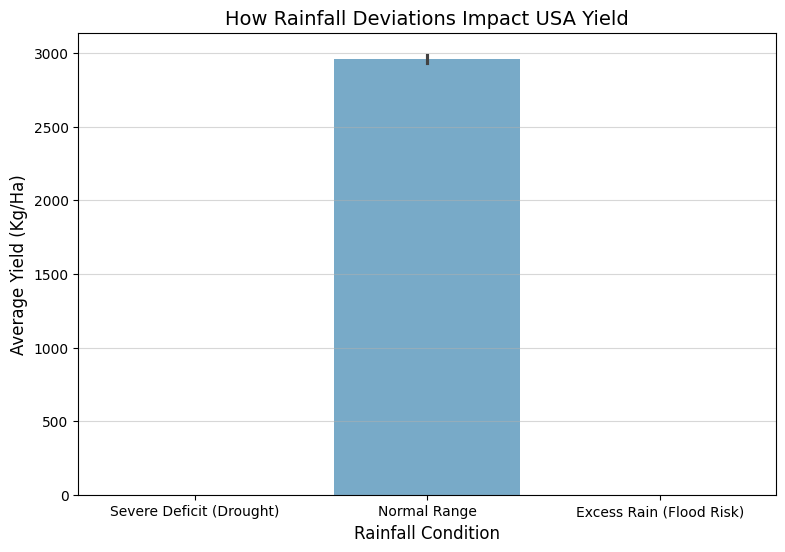

In [8]:
conditions_r = [
    (df_usa['Rainfall_Deviation'] < -50),
    (df_usa['Rainfall_Deviation'] >= -50) & (df_usa['Rainfall_Deviation'] <= 50),
    (df_usa['Rainfall_Deviation'] > 50)
]
categories_r = ['Severe Deficit (Drought)', 'Normal Range', 'Excess Rain (Flood Risk)']

df_usa['Rain_Shock_Category'] = np.select(conditions_r, categories_r, default='Unknown')

plt.figure(figsize=(9, 6))
sns.barplot(data=df_usa, x='Rain_Shock_Category', y='Yield', order=categories_r, palette='Blues')
plt.title('How Rainfall Deviations Impact USA Yield', fontsize=14)
plt.xlabel('Rainfall Condition', fontsize=12)
plt.ylabel('Average Yield (Kg/Ha)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

df_usa = df_usa.drop(columns=['Rain_Shock_Category'])

### Agricultural Momentum in the USA
Does a highly productive US county stay productive year-over-year? This scatter plot maps the `Yield_Rolling_Mean3` against the current `Yield`. A tight diagonal proves that baseline infrastructure and soil quality provide massive momentum.

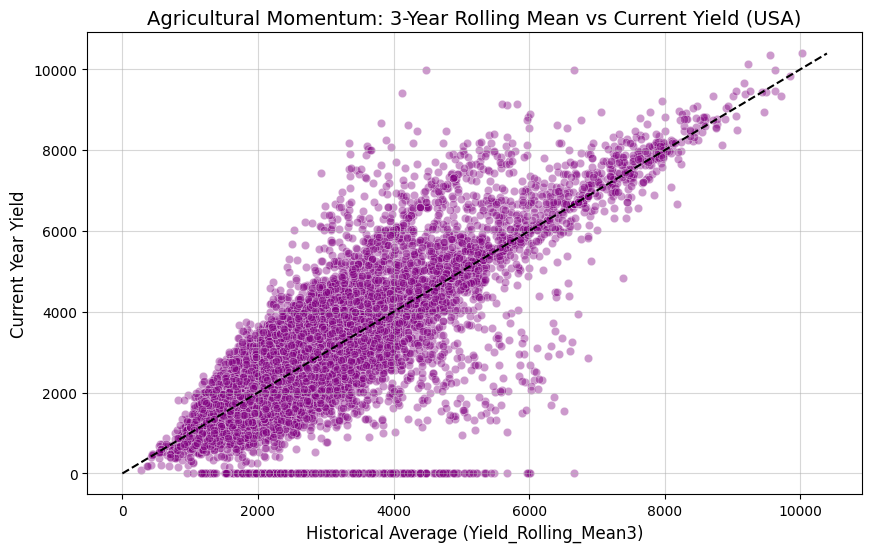

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_usa, x='Yield_Rolling_Mean3', y='Yield', alpha=0.4, color='purple')

# Reference line for 1:1 ratio
max_val = max(df_usa['Yield'].max(), df_usa['Yield_Rolling_Mean3'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--')

plt.title('Agricultural Momentum: 3-Year Rolling Mean vs Current Yield (USA)', fontsize=14)
plt.xlabel('Historical Average (Yield_Rolling_Mean3)', fontsize=12)
plt.ylabel('Current Year Yield', fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

### The Importance of Sowing Rainfall
Wheat seeds require optimal moisture to germinate. This plot visualizes how the amount of rain during the initial planting phase (`Sowing_Rainfall`) correlates with the final harvest volume months later.

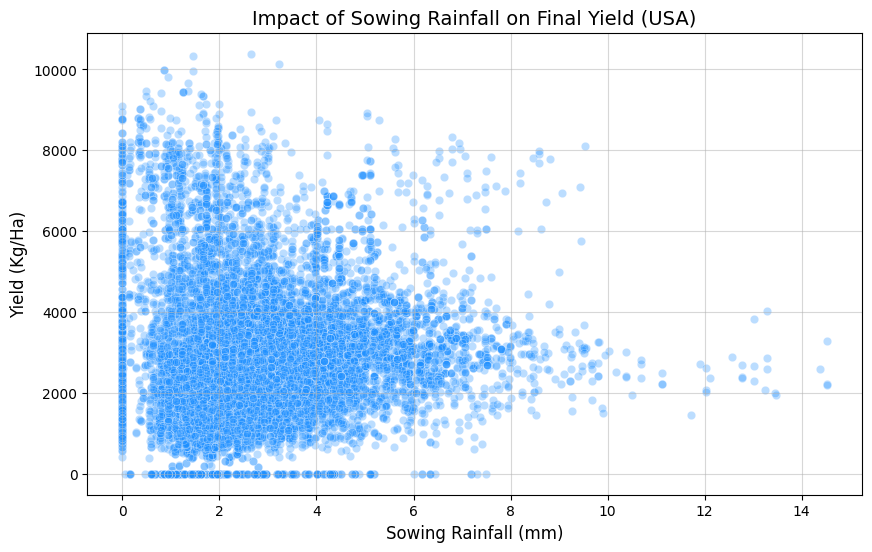

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_usa, x='Sowing_Rainfall', y='Yield', alpha=0.3, color='dodgerblue')
plt.title('Impact of Sowing Rainfall on Final Yield (USA)', fontsize=14)
plt.xlabel('Sowing Rainfall (mm)', fontsize=12)
plt.ylabel('Yield (Kg/Ha)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

### Top 10 Most Productive US Districts (Counties)
Which specific counties are the absolute powerhouses of US wheat production? We calculate the historical average yield for every district and plot the top 10.

/tmp/ipykernel_155/3229668422.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_districts.values, y=top_districts.index, palette='magma')


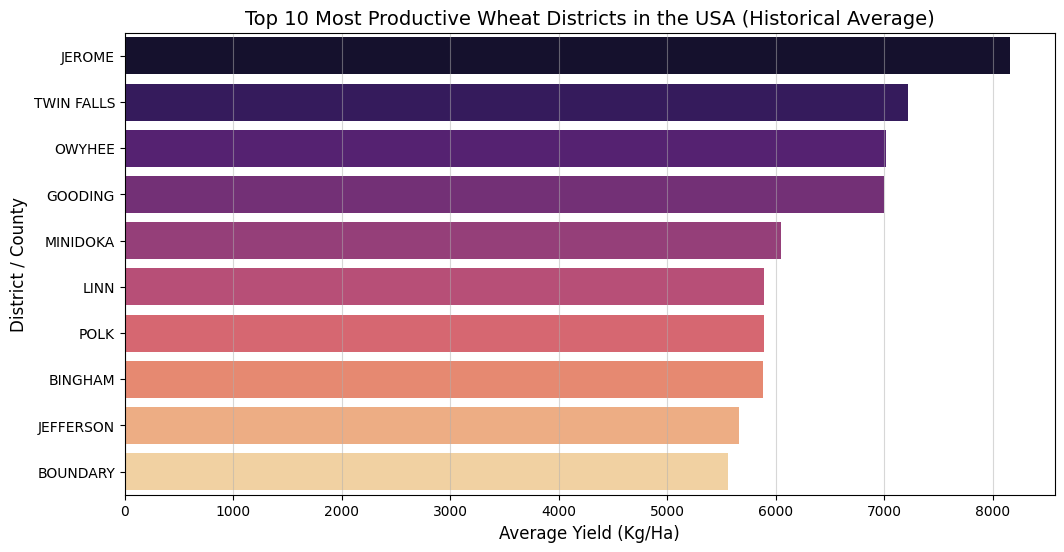

In [11]:
plt.figure(figsize=(12, 6))

# In the USA dataset, 'District' usually represents County or Agricultural District
top_districts = df_usa.groupby('District')['Yield'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_districts.values, y=top_districts.index, palette='magma')
plt.title('Top 10 Most Productive Wheat Districts in the USA (Historical Average)', fontsize=14)
plt.xlabel('Average Yield (Kg/Ha)', fontsize=12)
plt.ylabel('District / County', fontsize=12)
plt.grid(axis='x', alpha=0.5)
plt.show()

### Agricultural Volatility by State (Risk Analysis)
High average yield is good, but consistency is better. Here, we measure the Standard Deviation of yield for each state. States with high volatility are extremely vulnerable to climate shocks, experiencing boom and bust cycles.

/tmp/ipykernel_155/3246140093.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_volatility.index, y=state_volatility.values, palette='Reds_r')


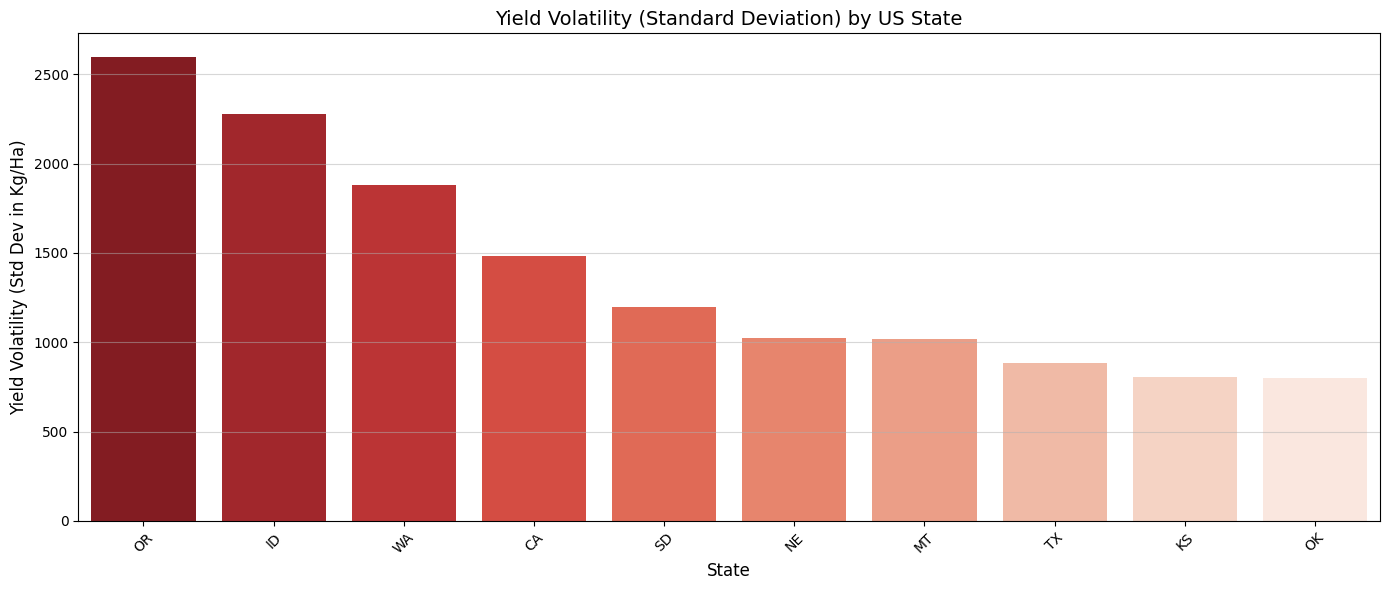

In [13]:
plt.figure(figsize=(14, 6))

state_volatility = df_usa.groupby('State')['Yield'].std().sort_values(ascending=False)

sns.barplot(x=state_volatility.index, y=state_volatility.values, palette='Reds_r')
plt.title('Yield Volatility (Standard Deviation) by US State', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Yield Volatility (Std Dev in Kg/Ha)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

### Decadal Progress: Agricultural Technology
To visualize the macro-impact of agricultural technology, better seeds, and modern fertilizers, we will group the data into decades and see if the baseline yield for the entire country is shifting upwards over time.

/tmp/ipykernel_155/2593814864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_usa, x='Decade', y='Yield', palette='Set2')


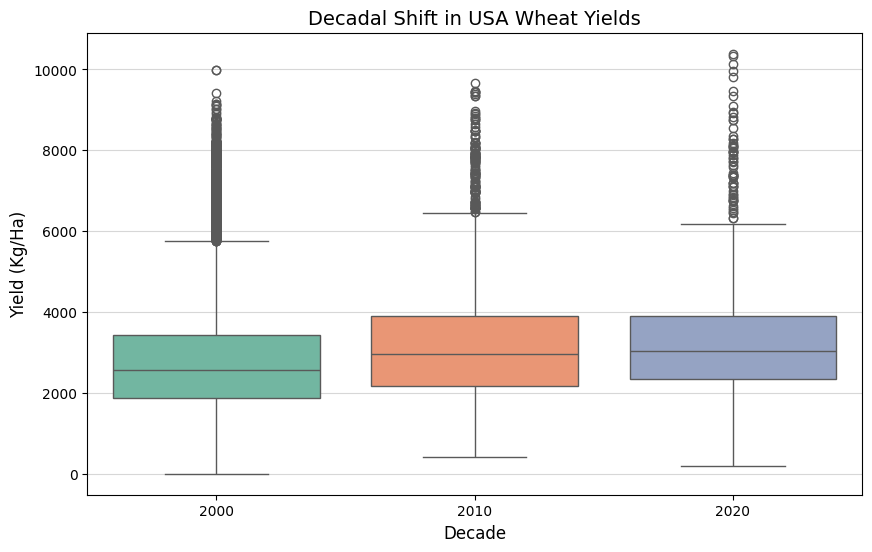

In [14]:
# Create a Decade column based on the Year
df_usa['Decade'] = (df_usa['Year'] // 10) * 10

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_usa, x='Decade', y='Yield', palette='Set2')
plt.title('Decadal Shift in USA Wheat Yields', fontsize=14)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Yield (Kg/Ha)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

# Drop the temporary Decade column
df_usa = df_usa.drop(columns=['Decade'])

### Climate Sweet Spot: Heat vs. Rain Hexbin
Where is the optimal "sweet spot" for American wheat? This hexbin plot acts as a density map, showing where the majority of harvests occur in relation to Average Season Temperature and Total Season Rainfall.

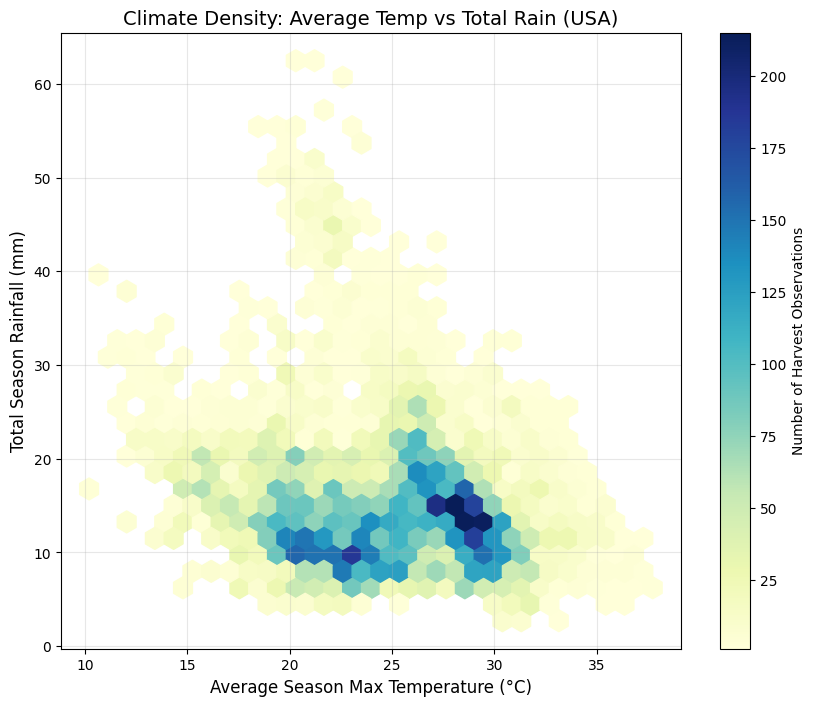

In [15]:
plt.figure(figsize=(10, 8))

# Hexbin plot shows the density of data points
hb = plt.hexbin(df_usa['Avg_Season_Tmax'], df_usa['Total_Season_Rain'],
                gridsize=30, cmap='YlGnBu', mincnt=1)

cb = plt.colorbar(hb, label='Number of Harvest Observations')
plt.title('Climate Density: Average Temp vs Total Rain (USA)', fontsize=14)
plt.xlabel('Average Season Max Temperature (°C)', fontsize=12)
plt.ylabel('Total Season Rainfall (mm)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()